In [56]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

# Problem 2

In [57]:
df = pd.read_csv('global-temperatures.csv')
df.head()

,year,temperature
0,1880,13.572500
1,1881,13.599167
2,1882,13.685000
3,1883,13.671667
4,1884,13.395000


In [58]:
X = df['year'].values.reshape(-1, 1)
y = df['temperature']

In [59]:
model = sklearn.linear_model.LinearRegression()
model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.01]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-4.337
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[467.97]


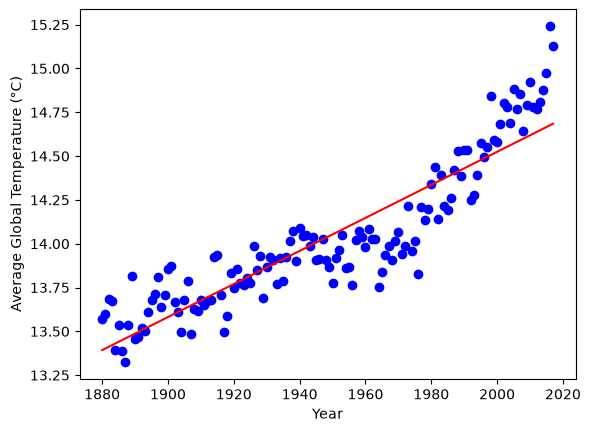

In [60]:
plt.scatter(X, y, color='blue', label='Data points')
# Plot the regression line
plt.plot(X, model.predict(X), color='red', label='Regression line')
plt.xlabel('Year')
plt.ylabel('Average Global Temperature (°C)')
plt.show()

In [61]:
error = np.sum((model.predict(X) - y) ** 2)
mse = error / len(y)
error_m = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (error / error_m)


In [62]:
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")

Mean Squared Error: 0.03213666009514228
R-squared: 0.8145436075330899
Slope: [ 0.00278169  0.00102013 -0.00687378  0.09032359  0.75411534]
Intercept: -15.43531432708495


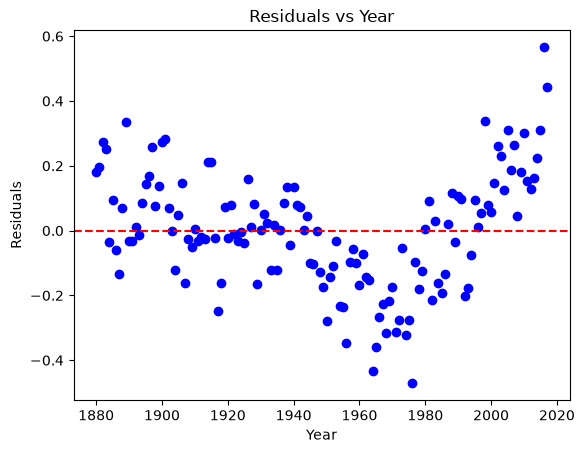

In [63]:
# plot residuals
residuals = y - model.predict(X)
plt.scatter(X, residuals, color='blue', label='Residuals')
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Year')
plt.ylabel('Residuals')
plt.title('Residuals vs Year')  
plt.show()

# Problem 3

In [64]:
df = pd.read_csv('auto-mpg.csv')
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year
0,18.0,8.0,307.0,130.0,3504.0,12.0,70.0
1,15.0,8.0,350.0,165.0,3693.0,11.5,70.0
2,18.0,8.0,318.0,150.0,3436.0,11.0,70.0
3,16.0,8.0,304.0,150.0,3433.0,12.0,70.0
4,17.0,8.0,302.0,140.0,3449.0,10.5,70.0


In [65]:
def linear_regression(X, y):
    model = LinearRegression()
    model.fit(X, y)
    return model

In [66]:
X = df[['displacement', 'horsepower', 'weight', 'acceleration', 'model_year']]
y = df['mpg']

model = linear_regression(X, y)

In [67]:
intercept = model.intercept_
slope = model.coef_

print(f"Intercept: {intercept}")
print(f"Slope: {slope}")

Intercept: -15.43531432708495
Slope: [ 0.00278169  0.00102013 -0.00687378  0.09032359  0.75411534]


In [68]:
error = np.mean((model.predict(X) - y) ** 2)
mse = error / len(y)
error_m = np.sum((y - np.mean(y)) ** 2)
r2 = 1 - (error / error_m) 

In [69]:
print(f"Mean Error: {mse}")
print(f"R-squared: {r2}")
print(f"Slope: {slope}")
print(f"Intercept: {intercept}")


Mean Error: 0.02964252470156333
R-squared: 0.9995121595000248
Slope: [ 0.00278169  0.00102013 -0.00687378  0.09032359  0.75411534]
Intercept: -15.43531432708495


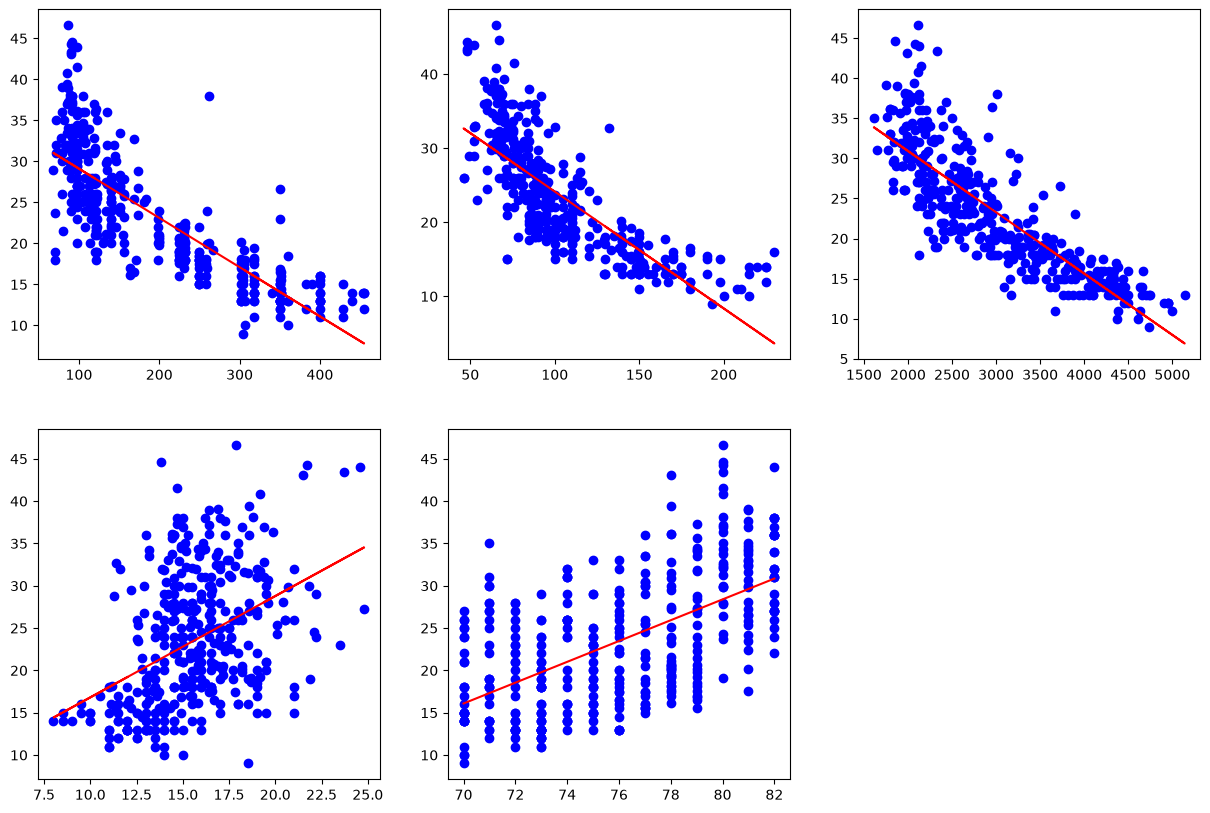

In [70]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

features = ['displacement', 'horsepower', 'weight', 'acceleration', 'model_year']
target = 'mpg'

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes = axes.flatten()

for i, feature in enumerate(features):
    ax = axes[i]

    ax.scatter(df[feature], df[target], color='blue', label='Data points')
    
    X_feature = df[[feature]]
    model = LinearRegression()
    model.fit(X_feature, df[target])
    
    ax.plot(df[feature], model.predict(X_feature), color='red', label='Regression line')

axes[5].set_visible(False)

plt.show()


### My linear regression function

In [84]:
class my_linear_regression:

    def __init__(self, lam: float = 0.0):
        self.lam = lam          
        self.a = None           
        self.coef_ = None       
        self.intercept_ = None 

    def _add_bias_column(self, X):
        M = X.shape[0]
        ones = np.ones((M, 1))
        return np.hstack([X, ones])   

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)

        X_ext = self._add_bias_column(X)     
        N_plus_1 = X_ext.shape[1]

        XtX = X_ext.T @ X_ext
        reg = self.lam * np.eye(N_plus_1)

        self.a = np.linalg.inv(XtX + reg) @ X_ext.T @ y

        self.coef_ = self.a[:-1]
        self.intercept_ = self.a[-1]
        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        X_ext = self._add_bias_column(X)
        return X_ext @ self.a

    def loss(self, X, y):
        y_pred = self.predict(X)
        return float(np.sum((y - y_pred) ** 2))

    def r2_score(self, X, y):
        y = np.asarray(y, dtype=float)
        y_pred = self.predict(X)
        E = np.sum((y - y_pred) ** 2)
        E_m = np.sum((y - np.mean(y)) ** 2)
        return float(1 - E / E_m)

In [ ]:
X = df[['horsepower', 'weight', 'acceleration', 'model_year']]
y = df['mpg']

model = my_linear_regression()
model.fit(X, y)

In [96]:
mse = model.loss(X, y) / len(y)
r2 = model.r2_score(X, y)

print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")
print(f"Slope: {model.coef_}")
print(f"Intercept: {model.intercept_}")

Mean Squared Error: 11.620035067349061
R-squared: 0.8087638022045306
Slope: [ 0.00287418 -0.00685209  0.08554726  0.75323316]
Intercept: -15.270033690481284


## doing regression with pairs of features